In [1]:
import nifty.re as jft
import jax.random as random
import jax
import jax.numpy as jnp
import numpy as np
# from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
# import matplotlib.colors as colors
# import seaborn as sns

In [2]:
# enable float64 precision
jax.config.update("jax_enable_x64", True)

# initialize JAX random key
seed = 42
key = random.PRNGKey(seed)

In [3]:
def inv_cov(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    return jax.scipy.linalg.inv(jax.scipy.linalg.toeplitz(cov0))

In [4]:
def inv_std(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    Cov = jax.scipy.linalg.toeplitz(cov0)
    L = jax.scipy.linalg.cholesky(Cov)
    return jax.scipy.linalg.inv(L)

In [5]:
def cov(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    return jax.scipy.linalg.toeplitz(cov0)

In [123]:
def compare_plot(samples, x, y_true, y_noise, compare="true"):

    y_samples = tuple(my_model(s) for s in samples)
    y_mean, y_std = jft.mean_and_std(y_samples)

    snr = np.max(np.abs(y_noise))/np.sqrt(np.mean(np.square(y_noise[:-50]-np.mean(y_noise[:-50]))))
    # calculate statistical measurements
    diff = y_mean - y_true
    abs_res = diff/y_std
    rmse = np.sqrt(np.mean(diff**2))
    print(rmse)
    print(rmse/np.max(y_true))

    # plot
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 10), sharex=True, gridspec_kw={"height_ratios": [3,1,1], "hspace":0})

    # vertical lines
    # for j in range(2):
    #      for i in range(len(x)):
    #         axes[j].axvline(i*5, c="lightgray", linestyle="--")

    # first plot
    axes[0].plot(x, y_noise, label="Noised data", c="tab:red", zorder=0) # Initial data with noise
    axes[0].fill_between(x, y_mean-y_std, y_mean+y_std, color="blue", alpha=0.5) # one sigma posterior
    axes[0].plot(x, y_mean, label=f"nifty mean", c="blue") # Mean posterior
    axes[0].plot(x, y_true, label=compare, c="tab:orange", zorder=10) # true signal without noise
    
    axes[0].set_ylabel(r"Signal")
    axes[0].legend()
    axes[0].spines["bottom"].set_linewidth(2.0)

    # residual plot
    axes[1].axhline(y=0, c="lightgray", linestyle="--")

    axes[1].fill_between(x, diff-y_std, diff+y_std, color="blue", alpha=0.5)
    axes[1].plot(x, diff, c="blue")

    axes[1].set_ylabel(r"Residual")
    y_max = np.max(np.abs(diff))*1.2
    axes[1].set_ylim(-y_max, y_max)

    # Absolute residual (uncertainty w.r.t. residual)
    axes[2].axhline(y=0, c="lightgray", linestyle="--")

    axes[2].plot(x, abs_res, c="red")
    y_max = np.max(np.abs(abs_res))*1.2
    axes[2].set_ylim(-y_max, y_max)
    axes[2].set_ylabel("Absolute Residual")

    axes[2].set_xlabel(r"$t$ [ns]")

    axes[0].set_title(f"PSNR={snr}")
    plt.show()

    return y_mean, y_std, diff, abs_res

In [8]:
def fieldmaker(shape, distances, prefix, **args):
    cfm = jft.CorrelatedFieldMaker(prefix=f"{prefix}")
    cfm.set_amplitude_total_offset(
        offset_mean=args["offset_mean"], offset_std=args["offset_std"]
    )
    args.pop("offset_mean")
    args.pop("offset_std")
    cfm.add_fluctuations(
        shape=shape,
        distances=distances,
        **args,
    )
    cf_model = cfm.finalize()

    return cf_model, cfm.power_spectrum

In [9]:
class SignalModel(jft.Model):
    def __init__(self, cf_model, window_mean_pos_prior, window_std_prior, x_grid):
        self.cf_model = cf_model
        self.window_mean_pos_prior = window_mean_pos_prior
        self.window_std_prior = window_std_prior
        self.x_grid = x_grid

        super().__init__(init=
                         self.cf_model.init | self.window_mean_pos_prior.init | self.window_std_prior.init
                         )

    def gaussian_window(self, x_grid, x0, sigma):
        return jnp.exp(-(x_grid-x0)**2/(2*sigma**2))

    def __call__(self, x):
        return self.cf_model(x) * self.gaussian_window(self.x_grid, self.window_mean_pos_prior(x), self.window_std_prior(x))
        # return self.cf_model(x) * self.gaussian_window(self.x_grid, 3.1e2, 30.)

# For a single channel

In [13]:
# measurement locations and data
t200 = np.load("data/time_200.npy")
d200 = np.load("data/true_trace_200.npy")
d200_noise = np.load("data/trace_200_simnoise.npy")

In [ ]:
A=2.89331354e-07
omega0=5.85403204e-01
gamma=2.70651972e-02
p=9.21301273e-01
C=-7.39389317e-03

Inv_Cov = inv_cov(len(d200_noise), A, omega0, gamma, p, C)
Inv_Std = inv_std(len(d200_noise), A, omega0, gamma, p, C)

noise_cov_inv = lambda x: jnp.matmul(Inv_Cov, x)
noise_std_inv = lambda x: jnp.matmul(Inv_Std, x)

In [118]:
# likelihood
cf_kwargs = {
    "offset_mean": 0,
    "offset_std": (1.71e-4, 1e-5),
    "fluctuations": (1e-3, 1e-4),
    "loglogavgslope": (5., 1.5),
    "flexibility": (1.0, 1.0),
    "asperity": (1.0e-8, 1.0e-8),
    "prefix": "",
}

x0 = jft.NormalPrior(mean=3.1e2, std=1e-10, name='mean_pos_window', shape=(1,))
sigma = jft.NormalPrior(mean=30., std=1e-21, name='std_window', shape=(1,))

shape = 200
distances = 5e-9

cf_model, ps = fieldmaker(shape=shape, distances=distances, **cf_kwargs)

my_model = SignalModel(cf_model, x0, sigma, t200)

lh = jft.Gaussian(data=d200_noise, noise_cov_inv=noise_cov_inv, noise_std_inv=noise_std_inv).amend(my_model)

key, subkey = random.split(key, 2)
init_pos = lh.init(subkey)
print("initial position: ", init_pos)
init_pos = jft.Vector(init_pos)
print("initial position vector: ", init_pos)

n_vi_iterations = 6
n_samples = 10
key, sampling_key = random.split(key, 2)

draw_linear_kwargs = dict(
    cg_name=None,
    cg_kwargs=dict(absdelta=1e-5 * jft.size(lh.domain), maxiter=100),
)

kl_kwargs = dict(minimize_kwargs=dict(name=None, xtol=1e-4, maxiter=35))

sample_mode = "linear_resample"

optimize_kl_args = dict(
    likelihood=lh,
    position_or_samples=init_pos,
    n_total_iterations=n_vi_iterations,
    n_samples=n_samples,
    key=sampling_key,
    draw_linear_kwargs=draw_linear_kwargs,
    kl_kwargs=kl_kwargs,
    sample_mode=sample_mode,
)

samples, state = jft.optimize_kl(**optimize_kl_args)

initial position:  {'asperity': Array(0.35431617, dtype=float64), 'flexibility': Array(-1.32866753, dtype=float64), 'fluctuations': Array(1.64462254, dtype=float64), 'loglogavgslope': Array(1.69422583, dtype=float64), 'mean_pos_window': Array([-0.9414686], dtype=float64), 'spectrum': Array([[-1.20498759e+00,  3.53187330e-02],
       [-8.42426193e-01,  5.54861298e-01],
       [ 7.33268796e-01, -1.33063824e+00],
       [-7.23535110e-01,  8.61987364e-01],
       [ 9.32204275e-01, -1.93143078e+00],
       [-8.32058272e-01,  1.80753046e-01],
       [ 1.26924950e-01, -1.58497666e+00],
       [ 5.15305190e-01,  1.59877313e+00],
       [-7.69206714e-01, -1.89439072e-01],
       [-8.82275191e-01, -9.08922447e-01],
       [ 5.46668466e-01, -1.02117710e+00],
       [-5.67507881e-01,  8.22608671e-01],
       [ 9.17575292e-01, -5.29900163e-01],
       [ 3.32403446e-02,  1.06303859e+00],
       [-2.63873351e-01, -6.47050433e-02],
       [-3.03450882e-01,  3.53067135e-01],
       [ 4.96475137e-01,  8

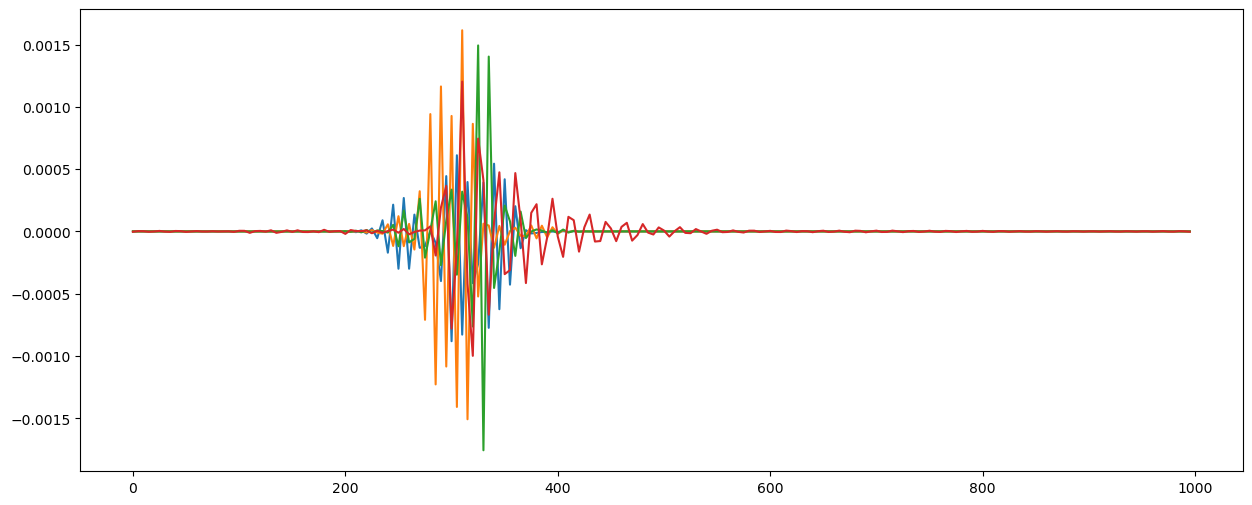

In [15]:
key, *subkeys = random.split(key, 4)
xi_samples = [jft.random_like(sk, my_model.domain) for sk in subkeys]

#  print(xi_samples[0]['spectrum'])

plt.figure(figsize=(15,6))
for i, xi in enumerate(xi_samples):
    plt.plot(t200, my_model(xi))
plt.plot(t200, d200)
plt.show()

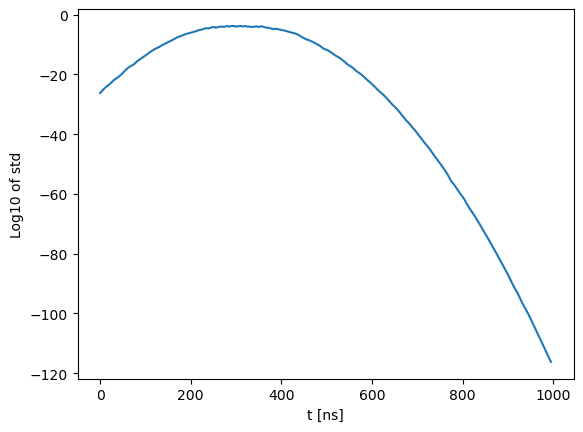

/tmp/ipykernel_227614/2216462594.py:6: RuntimeWarning: invalid value encountered in log10
  plt.plot(t200, np.log10(res[3]), label="res>0")
/tmp/ipykernel_227614/2216462594.py:7: RuntimeWarning: invalid value encountered in log10
  plt.plot(t200, np.log10(-res[3]), label="res<0")


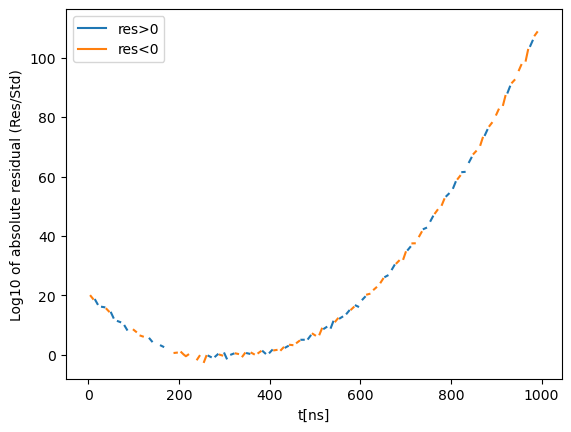

In [35]:
plt.plot(t200, np.log10(res[1]))
plt.xlabel("t [ns]")
plt.ylabel("Log10 of std")
plt.show()

plt.plot(t200, np.log10(res[3]), label="res>0")
plt.plot(t200, np.log10(-res[3]), label="res<0")
plt.legend()
plt.xlabel("t[ns]")
plt.ylabel("Log10 of absolute residual (Res/Std)")
plt.show()

# All channels

In [36]:
t200 = np.load("data/time_200.npy")
d = np.load("data/traces_allchan_200.npy")
d_true = np.load("data/true_allchan_200.npy")

In [92]:
def calc_RMSE(y_mean, y_true):
    # calculate statistical measurements
    diff = y_mean - y_true
    return np.sqrt(np.mean(diff**2)) #Root mean square

In [37]:
def show_progress(start, i, tot):
    now = time.time()
    eta = (now-start)*(tot-i)
    eta_str = f"{int(eta // 60)}m {int(eta % 60)}s"
    print(f"--- Iteration {i} | Estimated Time Remaining: {eta_str} ---", flush=True)
    return now

In [236]:
def compare(y_mean, y_std, x, y_true, y_noise, norm_rmse, compare="true"):

    snr = np.max(np.abs(y_true))/np.sqrt(np.mean(np.square(y_noise[:-50]-np.mean(y_noise[:-50]))))
    # calculate statistical measurements
    diff = y_mean - y_true
    abs_res = diff/y_std
    abs_res_peak = abs_res[np.argmax(np.abs(y_true))]

    # plot
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3,1], "hspace":0})

    # first plot
    axes[0].plot(x, y_noise, label="Noised data", c="gray", zorder=0) # Initial data with noise
    axes[0].fill_between(x, y_mean-y_std, y_mean+y_std, color="blue", alpha=0.5) # one sigma posterior
    axes[0].plot(x, y_mean, label=f"nifty mean", c="blue") # Mean posterior
    axes[0].plot(x, y_true, label=compare, c="tab:orange", zorder=10) # true signal without noise
    
    axes[0].set_ylabel(r"Signal")
    axes[0].legend()
    axes[0].spines["bottom"].set_linewidth(2.0)

    # residual plot
    axes[1].axhline(y=0, c="gray", linestyle="--")

    axes[1].fill_between(x, diff-y_std, diff+y_std, color="blue", alpha=0.5)
    axes[1].plot(x, diff, c="blue", label=rf"Abs_Res($t_{{peak}}$): {abs_res_peak:.4f}")

    axes[1].set_ylabel(r"Residual")
    y_max = np.max(np.abs(diff))*1.2
    axes[1].set_ylim(-y_max, y_max)
    axes[1].legend()

    axes[1].set_xlabel(r"$t$ [ns]")

    axes[0].set_title(f"PSNR={snr:.2f} | RMSE/true_peak={norm_rmse:.4f}")
    plt.show()

    return y_mean, y_std, diff, abs_res

In [39]:
from IPython.display import clear_output
import time

# Access the internal logger instance used by optimize_kl
nifty_internal_logger = jft.optimize_kl.__globals__['logger']

# Completely stub out its info and status message logging methods
nifty_internal_logger.info = lambda *args, **kwargs: None

In [ ]:
A=2.89331354e-07
omega0=5.85403204e-01
gamma=2.70651972e-02
p=9.21301273e-01
C=-7.39389317e-03

Inv_Cov = inv_cov(len(d200_noise), A, omega0, gamma, p, C)
Inv_Std = inv_std(len(d200_noise), A, omega0, gamma, p, C)

noise_cov_inv = lambda x: jnp.matmul(Inv_Cov, x)
noise_std_inv = lambda x: jnp.matmul(Inv_Std, x)

In [ ]:
# likelihood
tot = len(d)

n=0
sus = []
means = []
stds = []
rmses = []
norm_rmses = []
now = time.time()

for i in range(tot):

    clear_output(wait=True)
    now = show_progress(now, i, tot)

    # Print the ongoing history of found anomalies so far
    # if sus:
    #     print("\n[Anomalies Found So Far]:")
    #     for log_entry in sus:
    #         print(log_entry)
    #     print("-" * 30 + "\n")
    
    jax.clear_caches()
    cf_kwargs = {
    "offset_mean": 0,
    "offset_std": (1.71e-4, 1e-5),
    "fluctuations": (5e-4, 8e-4),
    "loglogavgslope": (7., 2.5),
    "flexibility": (1.0, 1.0),
    "asperity": (1.0e-8, 1.0e-8),
    "prefix": "",
    }

    x0 = jft.NormalPrior(mean=3.1e2, std=50, name='mean_pos_window', shape=(1,))
    sigma = jft.NormalPrior(mean=30., std=30, name='std_window', shape=(1,))

    shape = 200
    distances = 5e-9

    cf_model, ps = fieldmaker(shape=shape, distances=distances, **cf_kwargs)
    my_model = SignalModel(cf_model, x0, sigma, t200)

    lh = jft.Gaussian(data=d[i], noise_cov_inv=noise_cov_inv, noise_std_inv=noise_std_inv).amend(my_model)

    key, subkey = random.split(key, 2)
    init_pos = jft.Vector(lh.init(subkey))
    n_vi_iterations = 6
    n_samples = 4

    key, sampling_key = random.split(key, 2)

    draw_linear_kwargs = dict(
    cg_name=None,
    cg_kwargs=dict(absdelta=1e-5 * jft.size(lh.domain), maxiter=100),
    )

    kl_kwargs = dict(minimize_kwargs=dict(name=None, xtol=1e-4, maxiter=35))

    sample_mode = "linear_resample"

    optimize_kl_args = dict(
        likelihood=lh,
        position_or_samples=init_pos,
        n_total_iterations=n_vi_iterations,
        n_samples=n_samples,
        key=sampling_key,
        draw_linear_kwargs=draw_linear_kwargs,
        kl_kwargs=kl_kwargs,
        sample_mode=sample_mode,
        )

    s, state = jft.optimize_kl(**optimize_kl_args)

    y_samples = tuple(my_model(s) for s in s)
    y_mean, y_std = jft.mean_and_std(y_samples)
    means.append(y_mean)
    stds.append(y_std)

    rmse=calc_RMSE(y_mean, d_true[i])
    norm_rmse = rmse/np.max(np.abs(d_true[i])) 
    rmses.append(rmse)
    norm_rmses.append(norm_rmse)

    if norm_rmse > 0.1:
        # sus.append(f"IDX {i}: RMSE/max_amp={norm_rmse:.4f}")
        n += 1

clear_output(wait=True)
print("=== All Channels complete ===")
print(f"Total Suspicious Indices: {n}/{tot}\n")
# if sus:
#     print("Full Log of Anomalies:")
#     for log_entry in sus:
#         print(f"  * {log_entry}")

means = np.array(means)
stds = np.array(stds)
rmses = np.array(rmses)
norm_rmses = np.array(norm_rmses)

=== All Channels complete ===
Total Suspicious Indices: 1338/1344



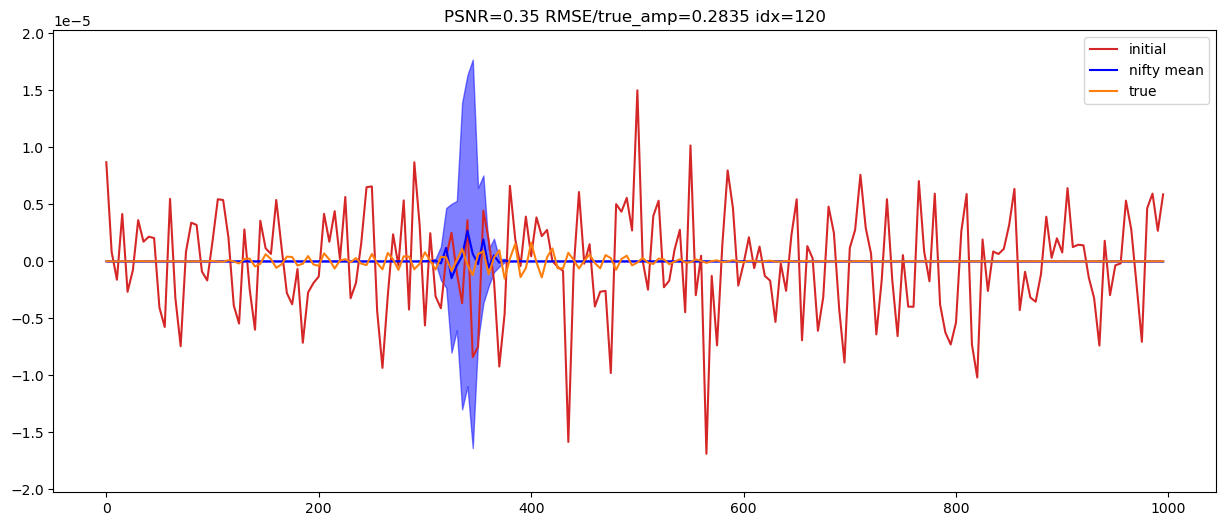

In [189]:
idx= np.random.randint(0,138)
snr = np.max(np.abs(d_true[idx]))/np.sqrt(np.mean(np.square(d[idx][:-50]-np.mean(d[idx][:-50]))))
plt.figure(figsize=(15, 6))
plt.plot(t200, d[idx], label="initial", c="tab:red")
plt.fill_between(t200, means[idx]-stds[idx], means[idx]+stds[idx], color="blue", alpha=0.5)
plt.plot(t200, means[idx], label="nifty mean", c="blue")
plt.plot(t200, d_true[idx], label="true", c="tab:orange")
plt.legend()
ymax = np.max(np.abs(d[idx]))*1.2
plt.ylim(-ymax, ymax)
plt.title(f"PSNR={snr:.2f} RMSE/true_amp={norm_rmses[idx]:.4f} idx={idx}")
plt.show()

133


/tmp/ipykernel_227614/376632903.py:6: RuntimeWarning: divide by zero encountered in divide
  abs_res = diff/y_std


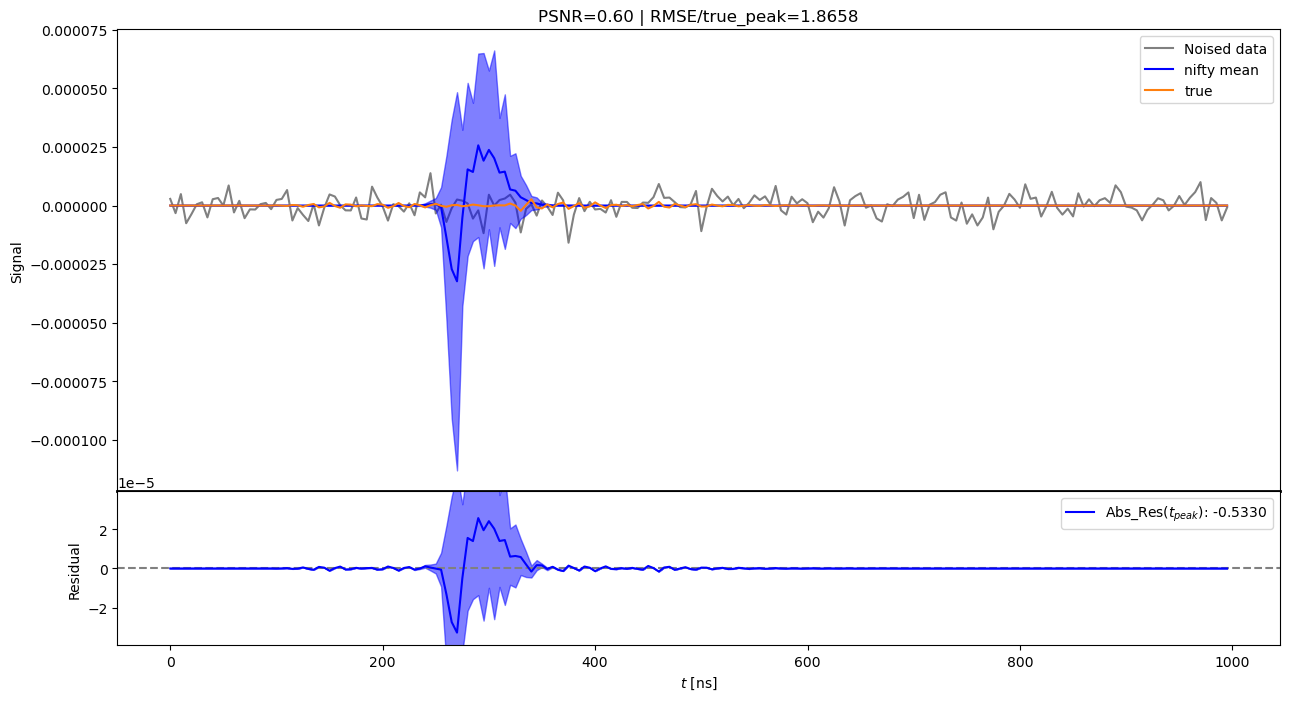

In [292]:
idx= np.random.randint(0,len(means))
print(idx)
res = compare(means[idx], stds[idx], t200, d_true[idx], d[idx], norm_rmses[idx])

In [310]:
np.save("results/allchan1/means.npy", means)
np.save("results/allchan1/stds.npy", stds)
np.save("results/allchan1/rmses.npy", rmses)
np.save("results/allchan1/norm_rmses.npy", norm_rmses)

# Generate noise from Cov

## Defining Functions

In [ ]:
import nifty.re as jft
import jax.random as random
import jax
import jax.numpy as jnp
import numpy as np
# from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
# import matplotlib.colors as colors
# import seaborn as sns

In [ ]:
# enable float64 precision
jax.config.update("jax_enable_x64", True)

# initialize JAX random key
seed = 42
key = random.PRNGKey(seed)

In [ ]:
def inv_cov(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    return jax.scipy.linalg.inv(jax.scipy.linalg.toeplitz(cov0))

In [ ]:
def inv_std(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    Cov = jax.scipy.linalg.toeplitz(cov0)
    L = jax.scipy.linalg.cholesky(Cov)
    return jax.scipy.linalg.inv(L)

In [ ]:
def cov(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    return jax.scipy.linalg.toeplitz(cov0)

In [ ]:
def std(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    Cov = jax.scipy.linalg.toeplitz(cov0)
    L = jax.scipy.linalg.cholesky(Cov)
    return L

In [ ]:
def compare_plot(samples, x, y_true, y_noise, compare="true"):

    y_samples = tuple(my_model(s) for s in samples)
    y_mean, y_std = jft.mean_and_std(y_samples)

    snr = np.max(np.abs(y_noise))/np.sqrt(np.mean(np.square(y_noise[:-50]-np.mean(y_noise[:-50]))))
    # calculate statistical measurements
    diff = y_mean - y_true
    abs_res = diff/y_std
    rmse = np.sqrt(np.mean(diff**2))
    print(rmse)
    print(rmse/np.max(y_true))

    # plot
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 10), sharex=True, gridspec_kw={"height_ratios": [3,1,1], "hspace":0})

    # vertical lines
    # for j in range(2):
    #      for i in range(len(x)):
    #         axes[j].axvline(i*5, c="lightgray", linestyle="--")

    # first plot
    axes[0].plot(x, y_noise, label="Noised data", c="tab:red", zorder=0) # Initial data with noise
    axes[0].fill_between(x, y_mean-y_std, y_mean+y_std, color="blue", alpha=0.5) # one sigma posterior
    axes[0].plot(x, y_mean, label=f"nifty mean", c="blue") # Mean posterior
    axes[0].plot(x, y_true, label=compare, c="tab:orange", zorder=10) # true signal without noise
    
    axes[0].set_ylabel(r"Signal")
    axes[0].legend()
    axes[0].spines["bottom"].set_linewidth(2.0)

    # residual plot
    axes[1].axhline(y=0, c="lightgray", linestyle="--")

    axes[1].fill_between(x, diff-y_std, diff+y_std, color="blue", alpha=0.5)
    axes[1].plot(x, diff, c="blue")

    axes[1].set_ylabel(r"Residual")
    y_max = np.max(np.abs(diff))*1.2
    axes[1].set_ylim(-y_max, y_max)

    # Absolute residual (uncertainty w.r.t. residual)
    axes[2].axhline(y=0, c="lightgray", linestyle="--")

    axes[2].plot(x, abs_res, c="red")
    y_max = np.max(np.abs(abs_res))*1.2
    axes[2].set_ylim(-y_max, y_max)
    axes[2].set_ylabel("Absolute Residual")

    axes[2].set_xlabel(r"$t$ [ns]")

    axes[0].set_title(f"PSNR={snr}")
    plt.show()

    return y_mean, y_std, diff, abs_res

In [ ]:
def fieldmaker(shape, distances, prefix, **args):
    cfm = jft.CorrelatedFieldMaker(prefix=f"{prefix}")
    cfm.set_amplitude_total_offset(
        offset_mean=args["offset_mean"], offset_std=args["offset_std"]
    )
    args.pop("offset_mean")
    args.pop("offset_std")
    cfm.add_fluctuations(
        shape=shape,
        distances=distances,
        **args,
    )
    cf_model = cfm.finalize()

    return cf_model, cfm.power_spectrum

In [ ]:
class SignalModel(jft.Model):
    def __init__(self, cf_model, window_mean_pos_prior, window_std_prior, x_grid):
        self.cf_model = cf_model
        self.window_mean_pos_prior = window_mean_pos_prior
        self.window_std_prior = window_std_prior
        self.x_grid = x_grid

        super().__init__(init=
                         self.cf_model.init | self.window_mean_pos_prior.init | self.window_std_prior.init
                         )

    def gaussian_window(self, x_grid, x0, sigma):
        return jnp.exp(-(x_grid-x0)**2/(2*sigma**2))

    def __call__(self, x):
        return self.cf_model(x) * self.gaussian_window(self.x_grid, self.window_mean_pos_prior(x), self.window_std_prior(x))
        # return self.cf_model(x) * self.gaussian_window(self.x_grid, 3.1e2, 30.)

In [ ]:
def show_progress(start, i, tot):
    now = time.time()
    eta = (now-start)*(tot-i)
    eta_str = f"{int(eta // 60)}m {int(eta % 60)}s"
    print(f"--- Iteration {i} | Estimated Time Remaining: {eta_str} ---", flush=True)
    return now

In [ ]:
def compare(y_mean, y_std, x, y_true, y_noise, norm_rmse, compare="true"):

    snr = np.max(np.abs(y_true))/np.sqrt(np.mean(np.square(y_noise[:-50]-np.mean(y_noise[:-50]))))
    # calculate statistical measurements
    diff = y_mean - y_true
    abs_res = diff/y_std
    abs_res_peak = abs_res[np.argmax(np.abs(y_true))]

    # plot
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3,1], "hspace":0})

    # first plot
    axes[0].plot(x, y_noise, label="Noised data", c="gray", zorder=0) # Initial data with noise
    axes[0].fill_between(x, y_mean-y_std, y_mean+y_std, color="blue", alpha=0.5) # one sigma posterior
    axes[0].plot(x, y_mean, label=f"nifty mean", c="blue") # Mean posterior
    axes[0].plot(x, y_true, label=compare, c="tab:orange", zorder=10) # true signal without noise
    
    axes[0].set_ylabel(r"Signal")
    axes[0].legend()
    axes[0].spines["bottom"].set_linewidth(2.0)

    # residual plot
    axes[1].axhline(y=0, c="gray", linestyle="--")

    axes[1].fill_between(x, diff-y_std, diff+y_std, color="blue", alpha=0.5)
    axes[1].plot(x, diff, c="blue", label=rf"Abs_Res($t_{{peak}}$): {abs_res_peak:.4f}")

    axes[1].set_ylabel(r"Residual")
    y_max = np.max(np.abs(diff))*1.2
    axes[1].set_ylim(-y_max, y_max)
    axes[1].legend()

    axes[1].set_xlabel(r"$t$ [ns]")

    axes[0].set_title(f"PSNR={snr:.2f} | RMSE/true_peak={norm_rmse:.4f}")
    plt.show()

    return y_mean, y_std, diff, abs_res

In [ ]:
from IPython.display import clear_output
import time

# Access the internal logger instance used by optimize_kl
nifty_internal_logger = jft.optimize_kl.__globals__['logger']

# Completely stub out its info and status message logging methods
nifty_internal_logger.info = lambda *args, **kwargs: None

## Test Generate Mock Signals

In [ ]:
A=2.89331354e-07
omega0=5.85403204e-01
gamma=2.70651972e-02
p=9.21301273e-01
C=-7.39389317e-03

Inv_Cov = inv_cov(len(d200_noise), A, omega0, gamma, p, C)
Inv_Std = inv_std(len(d200_noise), A, omega0, gamma, p, C)
Cov = cov(len(d200_noise), A, omega0, gamma, p, C)
Std = std(len(d200_noise), A, omega0, gamma, p, C)

noise_cov_inv = lambda x: jnp.matmul(Inv_Cov, x)
noise_std_inv = lambda x: jnp.matmul(Inv_Std, x)
noise_cov = lambda x: jnp.matmul(Cov, x)
noise_std = lambda x: jnp.matmul(Std, x)

In [ ]:
cf_kwargs = {
"offset_mean": 0,
"offset_std": (1.71e-4, 1e-5),
"fluctuations": (5e-4, 8e-4),
"loglogavgslope": (7., 2.5),
"flexibility": (1.0, 1.0),
"asperity": (1.0e-8, 1.0e-8),
"prefix": "",
}

x0 = jft.NormalPrior(mean=3.1e2, std=50, name='mean_pos_window', shape=(1,))
sigma = jft.NormalPrior(mean=30., std=30, name='std_window', shape=(1,))

shape = 200
distances = 5e-9

cf_model, ps = fieldmaker(shape=shape, distances=distances, **cf_kwargs)
my_model = SignalModel(cf_model, x0, sigma, t200)

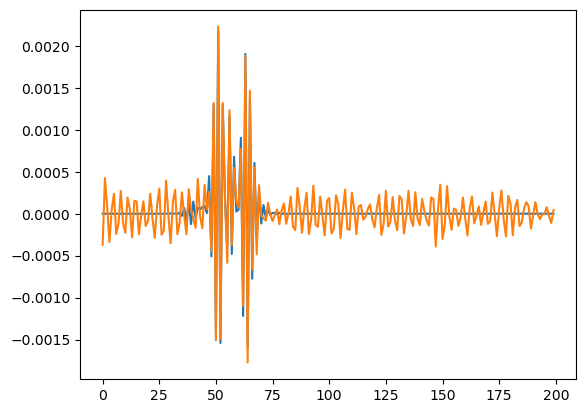

In [ ]:
key, *subkeys = random.split(key, 4)
xi_samples = [jft.random_like(sk, my_model.domain) for sk in subkeys]

mock_signal = my_model(xi_samples[0])

noise = noise_std(jft.random_like(subkeys[1], my_model.target))

mock_data = mock_signal + noise

plt.plot(mock_signal)
plt.plot(mock_data)

## Liklihood

In [ ]:
# likelihood
tot = len(d)

n=0
sus = []
means = []
stds = []
rmses = []
norm_rmses = []
now = time.time()

for i in range(tot):

    clear_output(wait=True)
    now = show_progress(now, i, tot)

    # Print the ongoing history of found anomalies so far
    # if sus:
    #     print("\n[Anomalies Found So Far]:")
    #     for log_entry in sus:
    #         print(log_entry)
    #     print("-" * 30 + "\n")
    
    jax.clear_caches()
    cf_kwargs = {
    "offset_mean": 0,
    "offset_std": (1.71e-4, 1e-5),
    "fluctuations": (5e-4, 8e-4),
    "loglogavgslope": (7., 2.5),
    "flexibility": (1.0, 1.0),
    "asperity": (1.0e-8, 1.0e-8),
    "prefix": "",
    }

    x0 = jft.NormalPrior(mean=3.1e2, std=50, name='mean_pos_window', shape=(1,))
    sigma = jft.NormalPrior(mean=30., std=30, name='std_window', shape=(1,))

    shape = 200
    distances = 5e-9

    cf_model, ps = fieldmaker(shape=shape, distances=distances, **cf_kwargs)
    my_model = SignalModel(cf_model, x0, sigma, t200)

    lh = jft.Gaussian(data=d[i], noise_cov_inv=noise_cov_inv, noise_std_inv=noise_std_inv).amend(my_model)

    key, subkey = random.split(key, 2)
    init_pos = jft.Vector(lh.init(subkey))
    n_vi_iterations = 6
    n_samples = 4

    key, sampling_key = random.split(key, 2)

    draw_linear_kwargs = dict(
    cg_name=None,
    cg_kwargs=dict(absdelta=1e-5 * jft.size(lh.domain), maxiter=100),
    )

    kl_kwargs = dict(minimize_kwargs=dict(name=None, xtol=1e-4, maxiter=35))

    sample_mode = "linear_resample"

    optimize_kl_args = dict(
        likelihood=lh,
        position_or_samples=init_pos,
        n_total_iterations=n_vi_iterations,
        n_samples=n_samples,
        key=sampling_key,
        draw_linear_kwargs=draw_linear_kwargs,
        kl_kwargs=kl_kwargs,
        sample_mode=sample_mode,
        )

    s, state = jft.optimize_kl(**optimize_kl_args)

    y_samples = tuple(my_model(s) for s in s)
    y_mean, y_std = jft.mean_and_std(y_samples)
    means.append(y_mean)
    stds.append(y_std)

    rmse=calc_RMSE(y_mean, d_true[i])
    norm_rmse = rmse/np.max(np.abs(d_true[i])) 
    rmses.append(rmse)
    norm_rmses.append(norm_rmse)

    if norm_rmse > 0.1:
        # sus.append(f"IDX {i}: RMSE/max_amp={norm_rmse:.4f}")
        n += 1

clear_output(wait=True)
print("=== All Channels complete ===")
print(f"Total Suspicious Indices: {n}/{tot}\n")
# if sus:
#     print("Full Log of Anomalies:")
#     for log_entry in sus:
#         print(f"  * {log_entry}")

means = np.array(means)
stds = np.array(stds)
rmses = np.array(rmses)
norm_rmses = np.array(norm_rmses)